# 스마트팜 SHAP 피처 선정 파이프라인
| 셀 | 내용 | 재실행 |
|---|---|---|
| CELL 1 | 임포트 / 상수 / 함수 정의 | 처음 한 번만 |
| CELL 2 | 데이터 로드 / 파생변수 / 집계 / 정제 | 처음 한 번만 |
| CELL 3 | SHAP 앙상블 + Robust 피처 선정 | 타겟 변경 시 |
| CELL 4 | 시각화 | 확인 시 |


## CELL 1 — 임포트 / 상수 / 함수 / 타겟 정의 (한 번만 실행)


In [3]:
import time, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from collections import Counter
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED      = 42
TOP_RATIO = 0.25
eps       = 1e-6
CSV_PATH  = "smartfarm_code/output/selected_smartfarm.csv"
OUT_DIR   = "output_m"

# ----------------------------------------------------------------
# 제거 컬럼: XXX + 다중공선성
# ----------------------------------------------------------------
COLLINEAR_DROP = [
    'hidden_tip_clog_level', 'hidden_blocked_tip_ratio', 'hidden_risk_stage',
    'cleaning_event_flag', 'flow_baseline_l_min',
    'tank_b_level_pct', 'acid_tank_level_pct',
    'tank_a_est_hours_to_empty', 'tank_b_est_hours_to_empty', 'acid_tank_est_hours_to_empty',
    'zone2_flow_l_min', 'zone3_flow_l_min',
    'zone2_pressure_kpa', 'zone3_pressure_kpa',
    'zone2_substrate_moisture_pct', 'zone3_substrate_moisture_pct',
    'zone2_substrate_ec_ds_m', 'zone3_substrate_ec_ds_m',
    'zone2_resistance', 'zone3_resistance',
    'relative_humidity_pct', 'mix_temp_c', 'raw_water_temp_c',
    'mix_flow_l_min', 'filter_pressure_out_kpa',
]

# ----------------------------------------------------------------
# 타겟 딕셔너리
# 각 타겟: 이상 발생 시 반드시 변하는 물리 지표
# leak   : 타겟 계산식에 직접 쓰인 컬럼 (data leakage 방지)
# 타겟 간 중복 허용 — 각 타겟이 다른 고장 관점을 담당
#
# motor_current_a        : 펌프 전기 부하 (직독값)
# zone1_resistance       : 팁 막힘     = zone_pressure / zone_flow
# wire_to_water_efficiency: 펌프 효율  = hydraulic_power / motor_power
# filter_delta_p_kpa     : 필터 막힘  = filter_in - filter_out
# salt_accumulation_delta: 염류 축적  = drain_ec - mix_ec
# flow_drop_rate         : 유량 감소율 = (baseline - flow) / baseline
# rpm_stability_index    : RPM 불안정 = |rpm - mean| / mean
# pid_error_ec           : 양액 EC 오차 = mix_ec - target_ec
# ----------------------------------------------------------------
target_dictionary = {
    'motor_current_a':          ['motor_power_kw', 'wire_to_water_efficiency', 'motor_temperature_c'],
    'zone1_resistance':         ['zone1_pressure_kpa', 'zone1_flow_l_min'],
    'wire_to_water_efficiency': ['motor_power_kw', 'differential_pressure_kpa',
                                 'flow_rate_l_min', 'hydraulic_power_kw'],
    'filter_delta_p_kpa':       ['filter_pressure_in_kpa', 'filter_pressure_out_kpa'],
    'salt_accumulation_delta':  ['drain_ec_ds_m', 'mix_ec_ds_m'],
    'flow_drop_rate':           ['flow_rate_l_min', 'flow_baseline_l_min'],
    'rpm_stability_index':      ['pump_rpm'],
    'pid_error_ec':             ['mix_ec_ds_m', 'mix_target_ec_ds_m'],
}

FAULT_CLASSES = {
    'motor_current_a':          {'class': 'PUMP_DEGRADATION', 'label': '펌프 전기 부하 이상'},
    'zone1_resistance':         {'class': 'TIP_CLOG',         'label': '팁(점적핀) 막힘'},
    'wire_to_water_efficiency': {'class': 'PUMP_EFFICIENCY',  'label': '펌프 효율 저하'},
    'filter_delta_p_kpa':       {'class': 'FILTER_CLOG',      'label': '필터 막힘'},
    'salt_accumulation_delta':  {'class': 'SALT_BUILDUP',     'label': '배관 염류 축적'},
    'flow_drop_rate':           {'class': 'FLOW_DROP',        'label': '유량 감소'},
    'rpm_stability_index':      {'class': 'RPM_INSTABILITY',  'label': 'RPM 불안정'},
    'pid_error_ec':             {'class': 'EC_ERROR',         'label': 'EC 제어 오차'},
}

print("CELL 1-A 완료: 상수/타겟 로드됨")



CELL 1-A 완료: 상수/타겟 로드됨


In [ ]:
def create_modeling_features(df):
    df_feat = df.copy()
    dt_s = df_feat.index.to_series().diff().dt.total_seconds().fillna(60) \
        if pd.api.types.is_datetime64_any_dtype(df_feat.index) else 60
# ── 파생변수 생성 ─────────────────────────────────────────────────
    # differential_pressure_kpa(차압) = discharge_pressure_kpa(펌프 토출압) - suction_pressure_kpa(펌프 흡입압)
    # → 펌프가 실제로 밀어낸 순수 압력. 급감 시 임펠러 손상·캐비테이션 의심
    df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']

    # filter_delta_p_kpa(필터 차압) = filter_pressure_in_kpa(필터 입구압) - filter_pressure_out_kpa(필터 출구압)
    # → 값이 클수록 필터 막힘 진행 중
    df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']

    # hydraulic_power_kw(수력 동력) = flow_rate_l_min(실제 유량) × differential_pressure_kpa(차압) / 60000
    # → 물에 실제로 전달된 유효 에너지(kW)
    df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000

    # wire_to_water_efficiency(펌프 효율) = hydraulic_power_kw(수력동력) / motor_power_kw(모터 전력)
    # → 낮을수록 펌프 노후화·손실 증가
    df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)

    # flow_baseline_l_min(기준 유량) = flow_rate_l_min(실제 유량) 최근 60분 이동평균, 1분 shift
    # → 현재 시점 누설 방지용 정상 기준선
    df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(60, min_periods=1).mean().shift(1)
    # 제거



    # flow_drop_rate(유량 감소율) = (flow_baseline_l_min(기준유량) - flow_rate_l_min(실제유량)) / flow_baseline_l_min(기준유량)
    # → 양수(+)일수록 유량 감소 중. 배관·팁 막힘 조기 신호
    df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)

    # temp_slope_c_per_s(모터 온도 변화율) = motor_temperature_c(모터 온도) 변화량 / dt_s(시간 초)
    # → 지속적인 양수(+)면 과부하·베어링 마모 진행 중
    df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_s

    # rpm_stability_index(RPM 불안정 지수) = |pump_rpm(현재RPM) - 최근10분평균| / 최근10분평균
    # → 클수록 RPM 요동. 공기 유입·난류 발생 의심
    rpm_mean = df_feat['pump_rpm'].rolling(10, min_periods=1).mean()
    df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

    # pid_error_ec(EC 제어 오차) = mix_ec_ds_m(실제 EC) - mix_target_ec_ds_m(목표 EC)
    # → 지속적으로 크면 조제기 밸브 노후화·비료 원액 고갈 의심
    df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']

    # pid_error_ph(pH 제어 오차) = mix_ph(실제 pH) - mix_target_ph(목표 pH)
    # → 오차 지속 시 산액 펌프 이상·원액 고갈 의심
    df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']

    # ph_instability_flag(pH 불안정 플래그) = mix_ph(실제 pH) > 6.5 이면 1
    # → pH 6.5 초과 시 칼슘·인산 침전 발생 구간. 배관 막힘 전조
    df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)

    # salt_accumulation_delta(염류 축적량) = drain_ec_ds_m(배액 EC) - mix_ec_ds_m(공급 EC)
    # → 양수(+)면 배지 내 염류 축적. 지속 시 배관·팁 막힘 유발
    df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']

    # calculated_vpd_kpa(VPD) = 포화증기압 - (포화증기압 × relative_humidity_pct(상대습도) / 100)
    # → 식물 수분 스트레스 지표. 권장 범위 0.5~1.2 kPa
    T, RH = df_feat['air_temp_c'], df_feat['relative_humidity_pct']
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3))
    df_feat['calculated_vpd_kpa'] = e_s - (e_s * (RH / 100))

    # daily_light_integral_proxy(일일 누적 광량 proxy) = light_ppfd_umol_m2_s(순간 광량) × dt_s(시간 초) / 1,000,000
    # → 1분 단위 광량 누적 중간값 (mol/m²)
    df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_s) / 1_000_000

    # daily_light_integral_mol_m2_d(일일 누적 광량) = daily_light_integral_proxy(누적 광량 proxy) 날짜별 누적합
    # → 하루 동안 식물이 받은 총 빛의 양. 빛 많은데 배액 늘면 팁 빠짐·뿌리 이상
    df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

    # raw_tank_level_change_pct_per_min(원수 탱크 감소율) = raw_tank_level_pct(원수 탱크 수위) 변화량 / dt_s(시간 초) × 60
    # → 관수 없이 수위 감소 시 누수. 펌프 가동 중 수위 불변 시 밸브 막힘
    df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_s / 60)
    # 제거


    # {tank}_est_hours_to_empty(탱크 고갈 예상 시간) = {tank}_level_pct(탱크 잔량) / 분당소모속도 / 60
    # → tank_a(A비료), tank_b(B비료), acid_tank(산탱크) 각각 계산
    # → 0에 수렴하면 보충 알람 필요
    for tank in ['tank_a', 'tank_b', 'acid_tank']:
        rate = (-df_feat[f'{tank}_level_pct'].diff().rolling(10, min_periods=1).mean()).clip(lower=eps)
        df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / rate) / 60

    # supply_balance_index(공급 밸런스 지수) = (zone1+zone2+zone3 유량합) / flow_rate_l_min(펌프 유량)
    # → 1이 정상. 낮으면 배관 누수. 특정 구역만 낮으면 해당 구역 팁 막힘
    zone_flow = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
    df_feat['supply_balance_index'] = zone_flow / (df_feat['flow_rate_l_min'] + eps)

    for i in range(1, 4):
        # zone{i}_moisture_response_pct(구역 수분 반응량) = zone{i}_substrate_moisture_pct(배지 수분) 변화량
        # → 급액 후 수분이 안 오르면 팁 막힘 또는 배지 불량
        df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()

        # zone{i}_resistance(구역 배관 저항) = zone{i}_pressure_kpa(구역 압력) / zone{i}_flow_l_min(구역 유량)
        # → 높을수록 해당 구역 팁 막힘 진행 중. 핵심 이상 신호
        df_feat[f'zone{i}_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)

        # zone{i}_ec_accumulation(구역 염류 축적) = zone{i}_substrate_ec_ds_m(구역 EC) - mix_ec_ds_m(공급 EC)
        # → 양수(+)가 지속되면 배지 내 염류 과잉 축적 → 팁·배관 막힘 유발
        df_feat[f'zone{i}_ec_accumulation'] = df_feat[f'zone{i}_substrate_ec_ds_m'] - df_feat['mix_ec_ds_m']
    return df_feat


def aggregate_sliding(df, window='10min', step='1min'):
    numeric = df.select_dtypes(include=[np.number]).columns
    return df[numeric].rolling(window=window).mean().resample(step).first().dropna()


def clean_collinear(df):
    df   = df.replace([np.inf, -np.inf], np.nan).fillna(df.mean())
    drop = [c for c in COLLINEAR_DROP if c in df.columns]
    df   = df.drop(columns=drop)
    print(f"  제거: {len(drop)}개 -> 잔존: {len(df.columns)}개")
    return df


def get_shap_importance_kmeans(X, y, target_name):
    import xgboost as xgb

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=8,
        device='cuda',
        tree_method='hist',
        random_state=SEED,
        verbosity=0,
    )
    model.fit(X, y)

    # KMeans 300개 — SHAP 속도 최적
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    km     = KMeans(n_clusters=min(300, len(X)), random_state=SEED, n_init='auto')
    km.fit(X_sc)
    X_bg   = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=X.columns)

    # XGBoost 내장 SHAP — 버전 충돌 없음
    dmat   = xgb.DMatrix(X_bg)
    sv     = model.get_booster().predict(dmat, pred_contribs=True)
    sv     = sv[:, :-1]  # 마지막 열(bias) 제거

    return pd.DataFrame({
        'Feature':         X.columns,
        'SHAP_Importance': np.abs(sv).mean(axis=0),
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)


def run_shap_ensemble(df, target_dict, top_ratio=TOP_RATIO):
    importance_results = {}
    top_per_target     = {}
    feat_vote_map      = {}
    n_targets          = len(target_dict)

    for target, leak_cols in target_dict.items():
        fc   = FAULT_CLASSES[target]
        drop = [target] + leak_cols
        X    = df.drop(columns=[c for c in drop if c in df.columns]).fillna(df.mean())
        y    = df[target].fillna(df[target].mean())

        print(f"  [{fc['class']}] {fc['label']} -- SHAP 계산 중...")
        imp_df = get_shap_importance_kmeans(X, y, target)
        importance_results[target] = imp_df

        top_n     = max(1, int(len(X.columns) * top_ratio))
        top_feats = imp_df.head(top_n)['Feature'].tolist()
        top_per_target[target] = set(top_feats)

        shap_map = imp_df.set_index('Feature')['SHAP_Importance'].to_dict()
        for feat in top_feats:
            val = shap_map.get(feat, 0)
            if feat not in feat_vote_map:
                feat_vote_map[feat] = {'votes': 1, 'class': fc['class'], 'label': fc['label'], 'shap': val}
            else:
                feat_vote_map[feat]['votes'] += 1
                if val > feat_vote_map[feat]['shap']:
                    feat_vote_map[feat].update({'class': fc['class'], 'label': fc['label'], 'shap': val})

        print(f"  완료: 상위 {top_n}개 선정\n")

    sets         = list(top_per_target.values())
    counter      = Counter([f for s in sets for f in s])
    robust       = [f for f, c in counter.most_common() if c >= 2]
    intersection = sorted(set.intersection(*sets))
    union        = sorted(set.union(*sets))

    print("=" * 65)
    print(f"1. 교집합 피처 ({len(intersection)}개 -- 모든 {n_targets}개 고장에 관여):")
    print(f"   {intersection}")
    print(f"\n2. Robust 피처 ({len(robust)}개 -- 2개 이상 고장에 관여) <- 오토인코더 추천:")
    print(f"   {robust}")
    print(f"\n3. 합집합 피처 ({len(union)}개 -- 전체 후보군):")
    print(f"   {union}")
    print("=" * 65)
    print(f"\n  {'votes':>5}  {'class':<22} {'label':<20}  피처")
    print("  " + "-" * 72)
    for feat in robust:
        info = feat_vote_map.get(feat, {'votes': 0, 'class': '-', 'label': '-'})
        print(f"  {info['votes']:>3}/{n_targets}  {info['class']:<22} {info['label']:<20}  {feat}")

    return {
        'intersection': intersection, 'robust': robust,
        'union': union, 'feat_vote': feat_vote_map,
    }, importance_results


def plot_shap_top10(shap_results, target_dict, top_n=10):
    n         = len(target_dict)
    ncols     = min(4, n)
    nrows     = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    axes_flat = axes.flatten() if n > 1 else [axes]
    for ax, (target, _) in zip(axes_flat, target_dict.items()):
        fc   = FAULT_CLASSES[target]
        data = shap_results[target].head(top_n)
        sns.barplot(x='SHAP_Importance', y='Feature', hue='Feature',
                    data=data, ax=ax, palette='Oranges_r', legend=False)
        ax.set_title(f"[Sliding] {target} Top {top_n}\n{fc['class']} / {fc['label']}",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_ylabel('')
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/shap_top10.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"저장 -> {OUT_DIR}/shap_top10.png")


print("CELL 1-B 완료: 모든 함수 로드됨")
print(f"타겟 수: {len(target_dictionary)}개  ->  {list(target_dictionary.keys())}")



CELL 1-B 완료: 모든 함수 로드됨
타겟 수: 8개  ->  ['motor_current_a', 'zone1_resistance', 'wire_to_water_efficiency', 'filter_delta_p_kpa', 'salt_accumulation_delta', 'flow_drop_rate', 'rpm_stability_index', 'pid_error_ec']


## CELL 2 — 데이터 로드 / 파생변수 / 집계 / 정제 (한 번만 실행)


In [11]:
print("STEP 1 / 데이터 로드")
df_raw = pd.read_csv(CSV_PATH)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.set_index('timestamp').sort_index()
df_copy = df_raw.copy()
print(f"  완료: {df_raw.shape}")

print("\nSTEP 2 / 파생변수 생성")
t0      = time.time()
df_feat = create_modeling_features(df_copy)
print(f"  완료: {df_feat.shape}  ({time.time()-t0:.1f}s)")

print("\nSTEP 3 / Sliding 윈도우 집계 (10min / 1min step)")
t0     = time.time()
df_agg = aggregate_sliding(df_feat)
print(f"  완료: {df_agg.shape}  ({time.time()-t0:.1f}s)")

print("\nSTEP 4 / 다중공선성 제거")
df_clean = clean_collinear(df_agg)
print(f"\nCELL 2 완료 -- df_clean: {df_clean.shape}")


STEP 1 / 데이터 로드
  완료: (129591, 44)

STEP 2 / 파생변수 생성
  완료: (129591, 73)  (0.1s)

STEP 3 / Sliding 윈도우 집계 (10min / 1min step)
  완료: (129590, 73)  (0.4s)

STEP 4 / 다중공선성 제거
  제거: 21개 -> 잔존: 52개

CELL 2 완료 -- df_clean: (129590, 52)


## CELL 3 — SHAP 앙상블 + Robust 피처 선정 (타겟 변경 시 재실행)


In [12]:
print("STEP 5 / SHAP 앙상블 실행")
t0 = time.time()
ensemble_lists, shap_results = run_shap_ensemble(df_clean, target_dictionary)
print(f"\n  총 소요: {time.time()-t0:.1f}s")

robust_features = ensemble_lists['robust']
FEAT_TO_CLASS   = {
    f: v['class'] for f, v in ensemble_lists['feat_vote'].items()
    if f in robust_features
}
X_train_ae = df_clean[[f for f in robust_features if f in df_clean.columns]].copy()

print(f"\nCELL 3 완료")
print(f"  X_train_ae     : {X_train_ae.shape}")
print(f"  robust_features: {robust_features}")
print(f"  FEAT_TO_CLASS  : {FEAT_TO_CLASS}")


STEP 5 / SHAP 앙상블 실행
  [PUMP_DEGRADATION] 펌프 전기 부하 이상 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [TIP_CLOG] 팁(점적핀) 막힘 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [PUMP_EFFICIENCY] 펌프 효율 저하 -- SHAP 계산 중...
  완료: 상위 11개 선정

  [FILTER_CLOG] 필터 막힘 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [SALT_BUILDUP] 배관 염류 축적 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [FLOW_DROP] 유량 감소 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [RPM_INSTABILITY] RPM 불안정 -- SHAP 계산 중...
  완료: 상위 12개 선정

  [EC_ERROR] EC 제어 오차 -- SHAP 계산 중...
  완료: 상위 12개 선정

1. 교집합 피처 (0개 -- 모든 8개 고장에 관여):
   []

2. Robust 피처 (29개 -- 2개 이상 고장에 관여) <- 오토인코더 추천:
   ['tank_a_level_pct', 'turbidity_ntu', 'hydraulic_power_kw', 'suction_pressure_kpa', 'zone1_resistance', 'calculated_vpd_kpa', 'air_temp_c', 'daily_light_integral_mol_m2_d', 'motor_temperature_c', 'pump_rpm', 'dosing_acid_ml_min', 'filter_pressure_in_kpa', 'flow_rate_l_min', 'bearing_vibration_rms_mm_s', 'raw_tank_level_pct', 'bearing_temperature_c', 'zone1_flow_l_min', 'light_ppfd_umol_m2_s', 'filter_delta_p_kpa', 'dis

## CELL 4 — 시각화 (확인 시 실행)


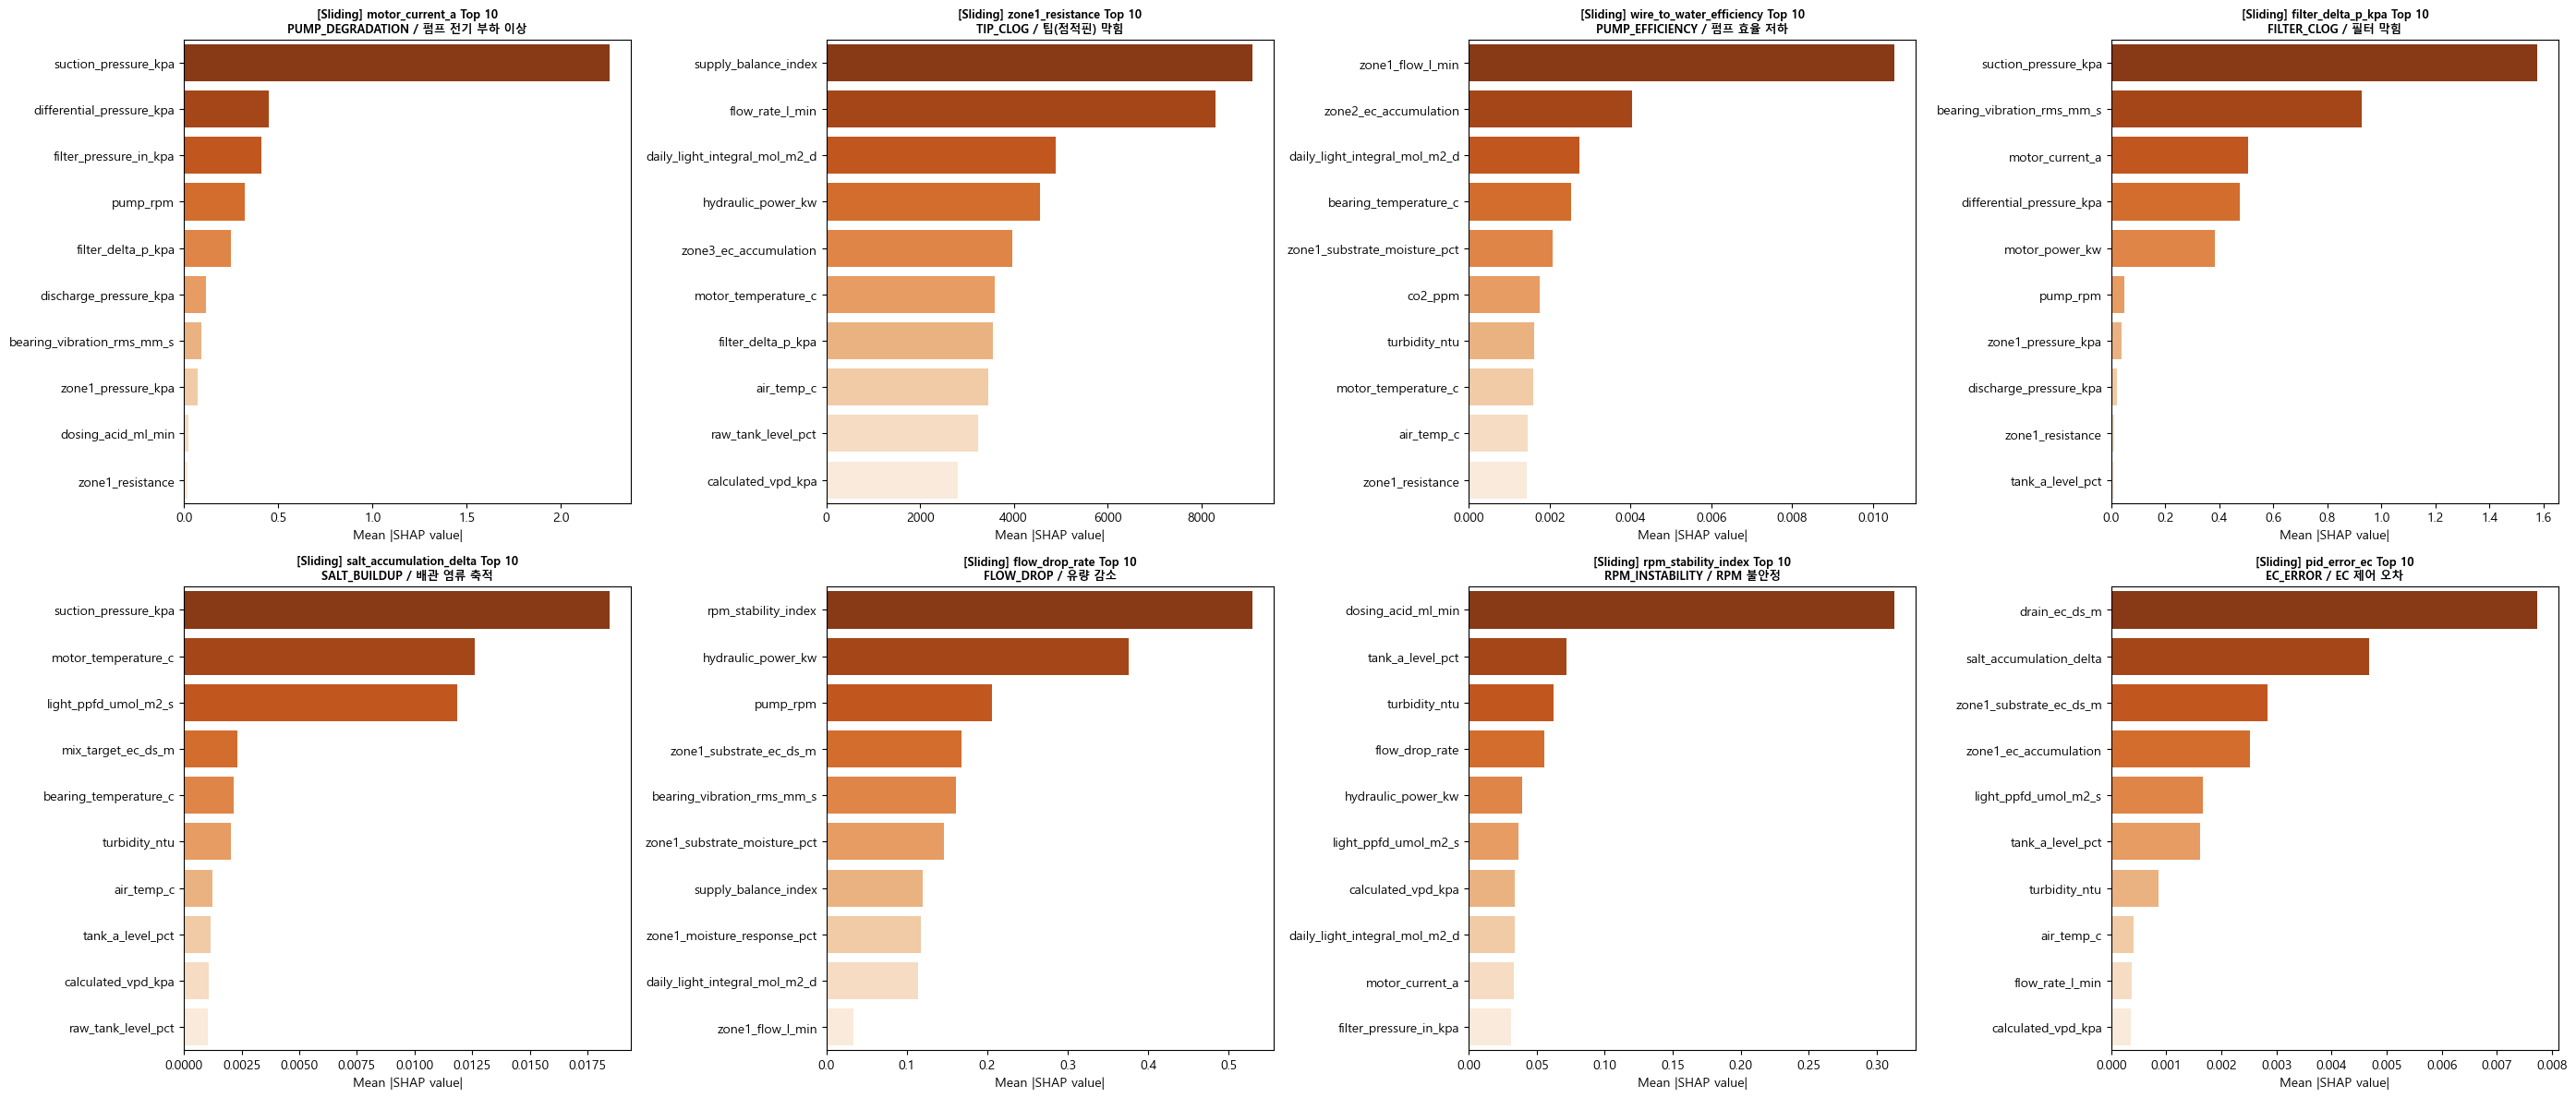

저장 -> output_m/shap_top10.png


In [16]:
plot_shap_top10(shap_results, target_dictionary)

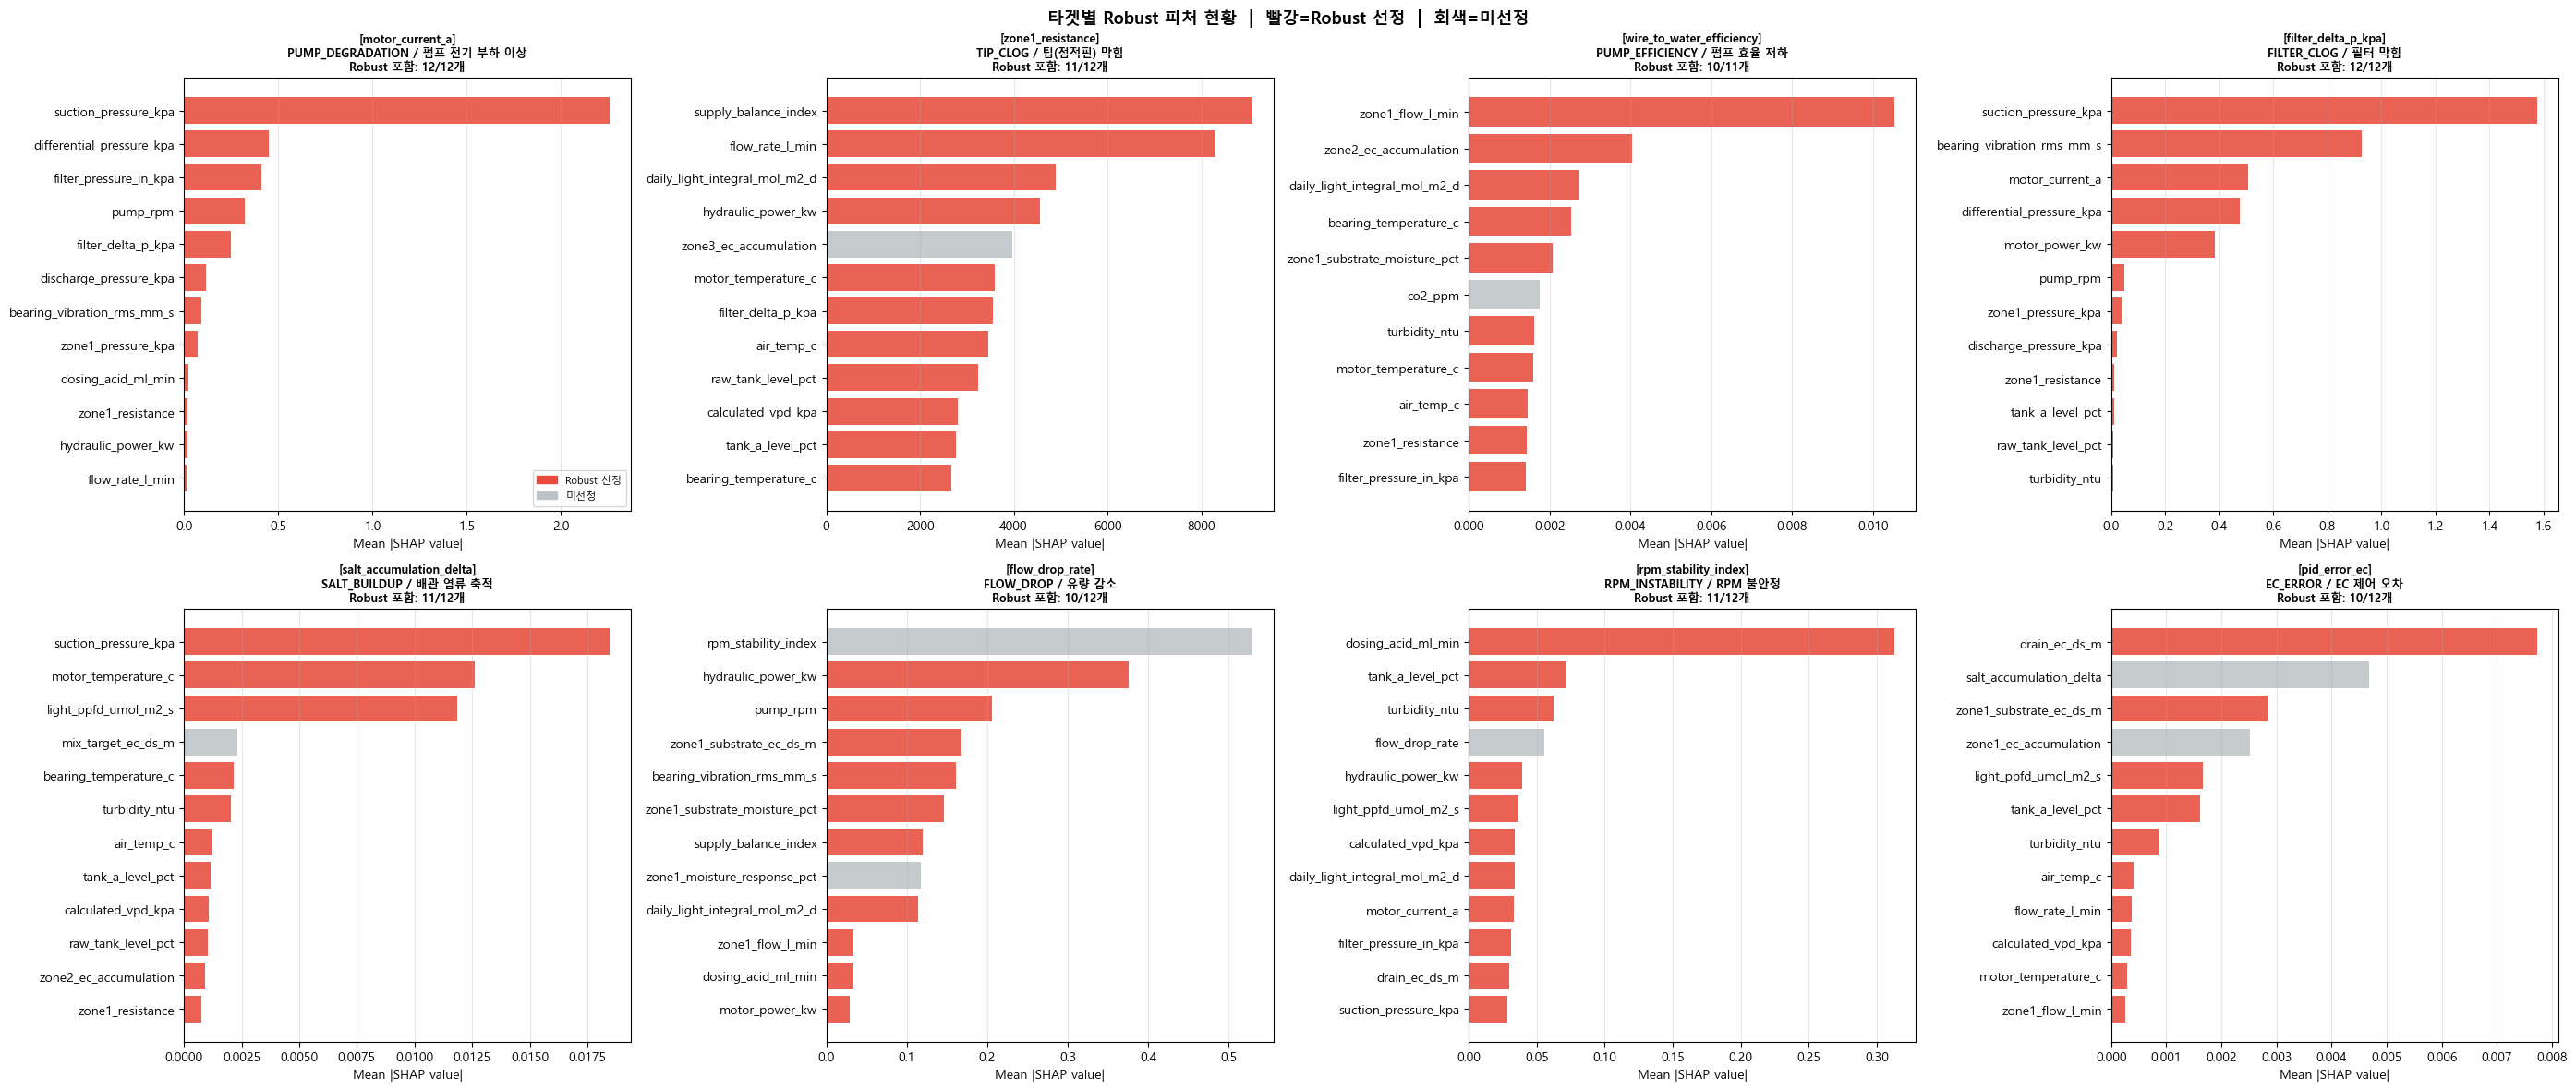

In [17]:
# CELL 5 — 타겟별 Robust 피처 (각각 독립 차트)

n         = len(target_dictionary)
ncols     = min(4, n)
nrows     = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes_flat = axes.flatten()

robust_set = set(robust_features)

for ax, (target, _) in zip(axes_flat, target_dictionary.items()):
    fc       = FAULT_CLASSES[target]
    imp_df   = shap_results[target]              # 전체 SHAP 결과
    top_n    = max(1, int(len(imp_df) * TOP_RATIO))
    selected = imp_df.head(top_n).copy()         # 이 타겟에서 뽑힌 상위 피처

    # Robust 여부 컬럼 추가
    selected['is_robust'] = selected['Feature'].isin(robust_set)
    colors = ['#e74c3c' if r else '#bdc3c7' for r in selected['is_robust']]

    ax.barh(selected['Feature'][::-1], selected['SHAP_Importance'][::-1],
            color=colors[::-1], alpha=0.88)
    ax.set_title(f"[{target}]\n{fc['class']} / {fc['label']}\n"
                 f"Robust 포함: {selected['is_robust'].sum()}/{top_n}개",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=.3)

    # 범례 (한 번만)
    if ax == axes_flat[0]:
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#e74c3c', label='Robust 선정'),
            Patch(color='#bdc3c7', label='미선정'),
        ], fontsize=8, loc='lower right')

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle(f'타겟별 Robust 피처 현황  |  빨강=Robust 선정  |  회색=미선정',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/robust_per_target.png", dpi=130, bbox_inches='tight')
plt.show()